In [84]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

sns.set_theme(style="whitegrid")

In [85]:
df = pd.read_csv("Churn_Modelling.csv")

print(df.shape)

df.head()

(10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [86]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


In [87]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

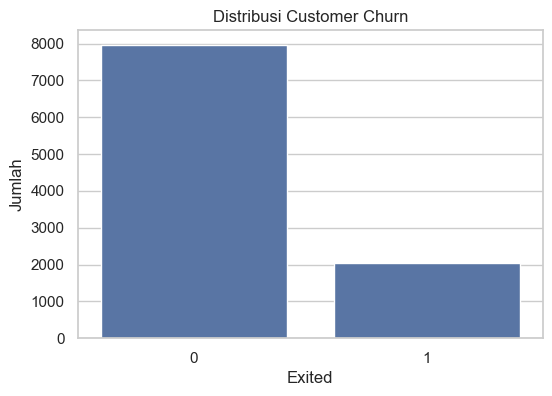

In [88]:
plt.figure(figsize=(6,4))

sns.countplot(
    x=df["Exited"]
)

plt.title("Distribusi Customer Churn")
plt.xlabel("Exited")
plt.ylabel("Jumlah")

plt.show()

In [89]:
print(
    df["Exited"].value_counts(normalize=True)*100
)

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


In [90]:
df = df.drop(
    columns=[
        "RowNumber",
        "CustomerId",
        "Surname"
    ]
)

In [91]:
df = pd.get_dummies(
    df,
    columns=[
        "Geography",
        "Gender"
    ],
    drop_first=True
)

In [92]:
for col in df.columns:
    if df[col].dtype == bool:
        df[col] = df[col].astype(int)

In [93]:
X = df.drop("Exited", axis=1)

y = df["Exited"]

In [94]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [95]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

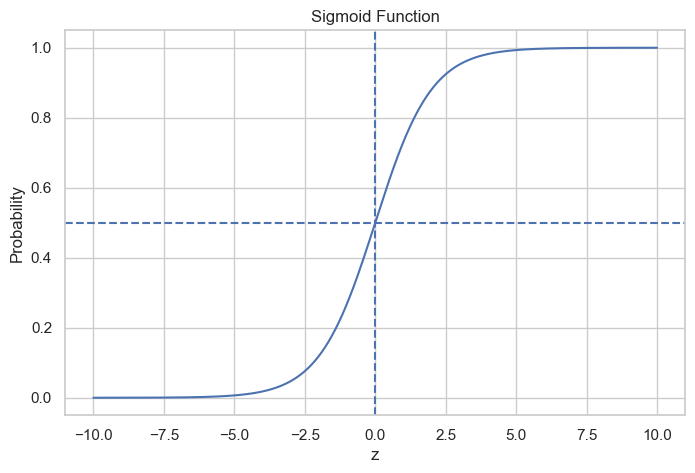

In [96]:
z = np.linspace(-10,10,1000)

sigmoid = 1/(1+np.exp(-z))

plt.figure(figsize=(8,5))

plt.plot(z,sigmoid)

plt.axhline(
    y=0.5,
    linestyle="--"
)

plt.axvline(
    x=0,
    linestyle="--"
)

plt.title("Sigmoid Function")

plt.xlabel("z")

plt.ylabel("Probability")

plt.show()

In [97]:
lr = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr.fit(
    X_train_scaled,
    y_train
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [98]:
z_score = lr.decision_function(
    X_test_scaled
)

In [99]:
y_prob = lr.predict_proba(
    X_test_scaled
)[:,1]

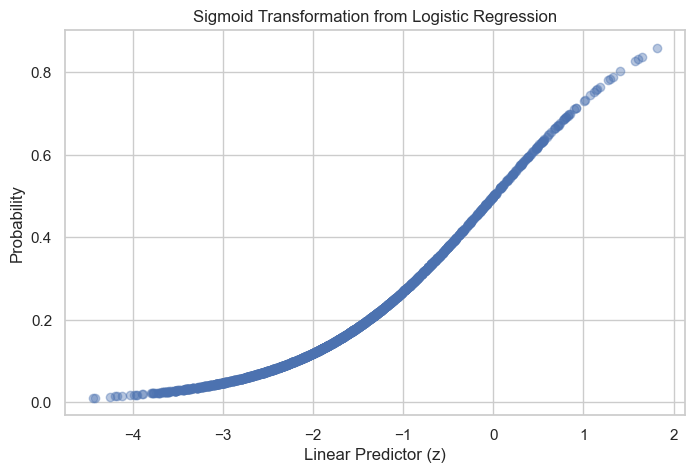

In [100]:
plt.figure(figsize=(8,5))

plt.scatter(
    z_score,
    y_prob,
    alpha=0.4
)

plt.xlabel("Linear Predictor (z)")
plt.ylabel("Probability")

plt.title(
    "Sigmoid Transformation from Logistic Regression"
)

plt.show()

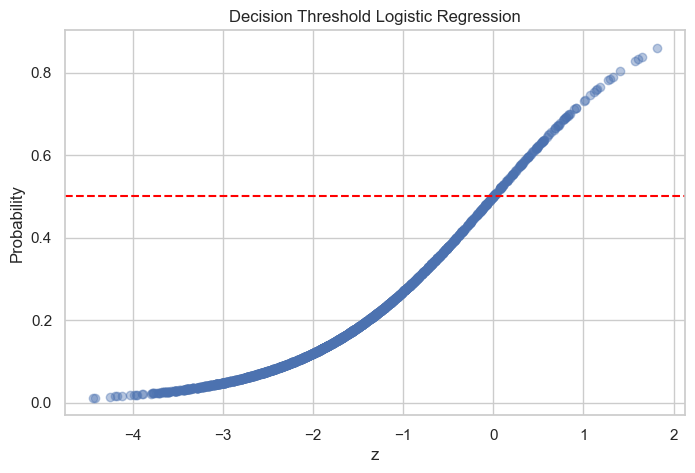

In [101]:
plt.figure(figsize=(8,5))

plt.scatter(
    z_score,
    y_prob,
    alpha=0.4
)

plt.axhline(
    y=0.5,
    linestyle="--",
    color="red"
)

plt.title(
    "Decision Threshold Logistic Regression"
)

plt.xlabel("z")

plt.ylabel("Probability")

plt.show()

In [102]:
y_pred = lr.predict(
    X_test_scaled
)

In [103]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

print("Accuracy :", round(accuracy,4))
print("Precision:", round(precision,4))
print("Recall   :", round(recall,4))
print("F1 Score :", round(f1,4))
print("ROC AUC  :", round(roc_auc,4))

Accuracy : 0.808
Precision: 0.5891
Recall   : 0.1867
F1 Score : 0.2836
ROC AUC  : 0.7748


In [104]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



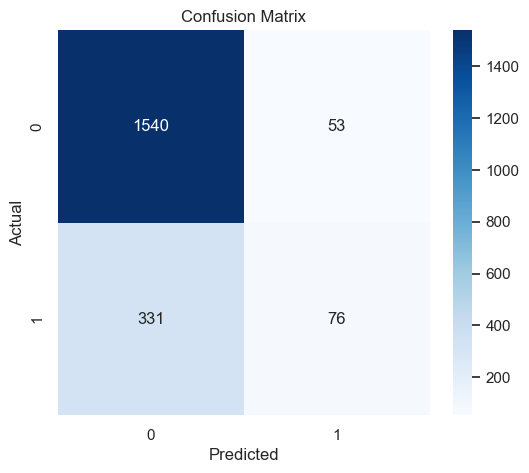

In [105]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

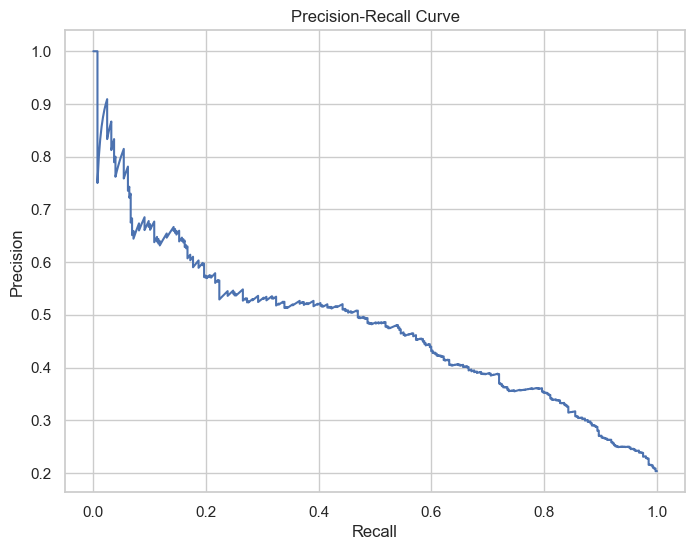

In [106]:
precision_curve, recall_curve, _ = precision_recall_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8,6))

plt.plot(
    recall_curve,
    precision_curve
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.show()

In [107]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_[0]
})

coef_df = coef_df.sort_values(
    by="Coefficient",
    ascending=False
)

coef_df

,Feature,Coefficient
1,Age,0.738847
8,Geography_Germany,0.356679
3,Balance,0.160622
7,EstimatedSalary,0.047725
9,Geography_Spain,0.018907
2,Tenure,-0.020071
5,HasCrCard,-0.032208
4,NumOfProducts,-0.070292
0,CreditScore,-0.085986
10,Gender_Male,-0.260851


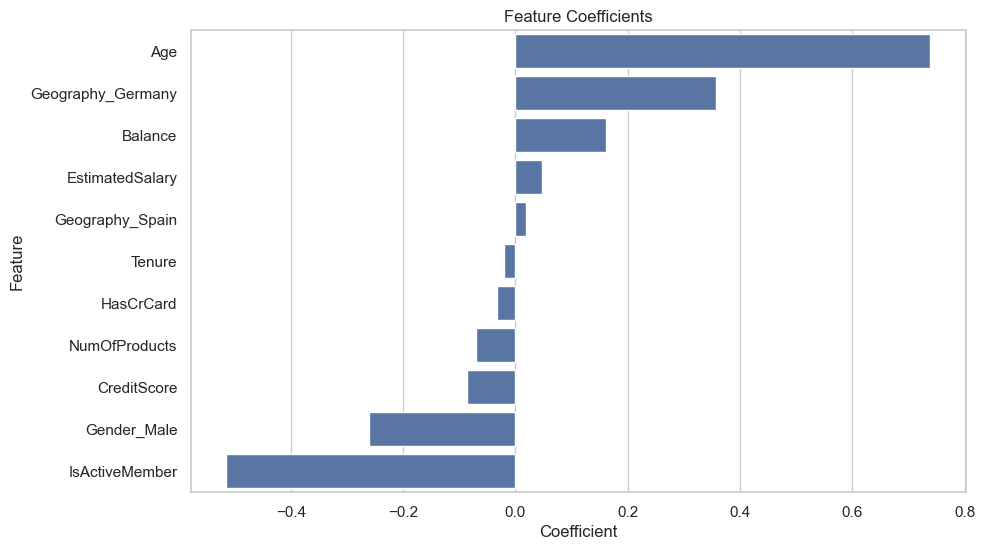

In [108]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=coef_df,
    x="Coefficient",
    y="Feature"
)

plt.title(
    "Feature Coefficients"
)

plt.show()

In [109]:
odds_ratio = np.exp(
    lr.coef_[0]
)

odds_df = pd.DataFrame({
    "Feature": X.columns,
    "OddsRatio": odds_ratio
})

odds_df = odds_df.sort_values(
    by="OddsRatio",
    ascending=False
)

odds_df

,Feature,OddsRatio
1,Age,2.093520
8,Geography_Germany,1.428578
3,Balance,1.174241
7,EstimatedSalary,1.048882
9,Geography_Spain,1.019087
2,Tenure,0.980129
5,HasCrCard,0.968306
4,NumOfProducts,0.932122
0,CreditScore,0.917607
10,Gender_Male,0.770396


In [110]:
print("Intercept:")
print(lr.intercept_)

print("\nCoefficients:")
for feature, coef in zip(X.columns, lr.coef_[0]):
    print(feature, coef)

Intercept:
[-1.64591685]

Coefficients:
CreditScore -0.08598645820445443
Age 0.7388467090007923
Tenure -0.020071211833606918
Balance 0.1606221564543801
NumOfProducts -0.07029166180296693
HasCrCard -0.03220758148097739
IsActiveMember -0.5154850613592583
EstimatedSalary 0.04772528431772233
Geography_Germany 0.3566792550687848
Geography_Spain 0.018907129561022418
Gender_Male -0.2608510174969197
